<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/03_01_Computer_Vision_and_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Intro to CNN and Comp. Vision using tensorflow

Get the data

In [1]:
import zipfile
# images are from the Food101 dataset
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-06-12 05:54:43--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   163MB/s    in 0.6s    

2026-06-12 05:54:44 (163 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [2]:
# inspect the data

!ls pizza_steak # ls stands for list

test  train


In [3]:
!ls pizza_steak/train/

pizza  steak


In [4]:
# !ls pizza_steak/train/pizza/

In [5]:
import os

# walk through the dir and list the no. files in pizza_steak directory
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} files in {dirpath}")

There are 2 directories and 0 files in pizza_steak
There are 2 directories and 0 files in pizza_steak/test
There are 0 directories and 250 files in pizza_steak/test/pizza
There are 0 directories and 250 files in pizza_steak/test/steak
There are 2 directories and 0 files in pizza_steak/train
There are 0 directories and 750 files in pizza_steak/train/pizza
There are 0 directories and 750 files in pizza_steak/train/steak


In [6]:
# another way to see the no. of files in a directory
num_steak_images = len(os.listdir("pizza_steak/train/steak"))
num_steak_images # no. of steak images in train directory

750

In [7]:
# get classnames programatically

import pathlib
import numpy as np

data_dir = pathlib.Path("pizza_steak/train")
# data_dir
class_names = np.array(sorted(item.name for item in data_dir.glob('*')))
print(class_names)

['pizza' 'steak']


Get to know the data

In [8]:
import matplotlib.pyplot as plt # to plot pixels
import matplotlib.image as mpimg # for pixel to array conversion to feed into the model
import random

pizza_steak/train/steak
name: 3790962.jpg


array([[[213, 178, 148],
        [199, 164, 134],
        [201, 167, 139],
        ...,
        [243, 245, 110],
        [240, 241, 101],
        [236, 238,  95]],

       [[212, 177, 147],
        [201, 166, 136],
        [203, 169, 141],
        ...,
        [246, 246, 136],
        [242, 240, 127],
        [238, 237, 121]],

       [[211, 177, 149],
        [204, 170, 142],
        [205, 171, 143],
        ...,
        [254, 249, 193],
        [249, 245, 184],
        [245, 241, 178]],

       ...,

       [[253, 255, 252],
        [253, 255, 252],
        [253, 255, 252],
        ...,
        [255, 255, 253],
        [254, 254, 252],
        [254, 254, 252]],

       [[253, 255, 252],
        [253, 255, 252],
        [253, 255, 252],
        ...,
        [251, 251, 249],
        [248, 248, 246],
        [246, 246, 244]],

       [[253, 255, 252],
        [253, 255, 252],
        [253, 255, 252],
        ...,
        [245, 245, 243],
        [241, 241, 239],
        [238, 238, 236]]], dtype=uint8)
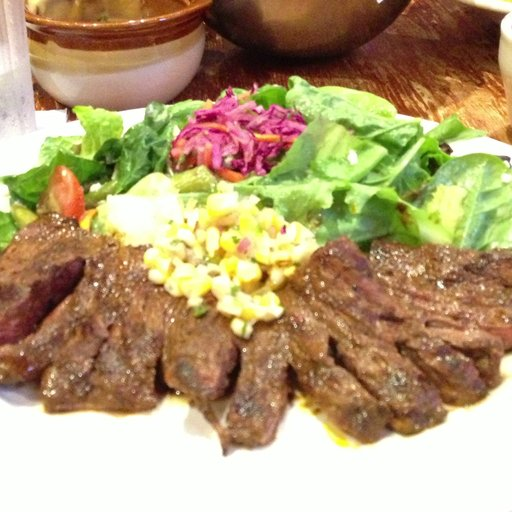

In [9]:
def view_random_image(target_dir, target_class):
  # setup target directory
  target_folder = target_dir + target_class
  print(target_folder)

  # get a random image path
  random_image = random.sample(os.listdir(target_folder), 1) # this means to randomly sample 1 image from target_folder
  # random.sample returns a list, use [0] to get the item as a str
  print(f"name: {random_image[0]}")

  # read in the image and plot using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0]) # converts image to array
  return(img)
  plt.title(target_class)
  plt.axis("off") # turns of the x, y axis grid

  # get the shape of the image
  print(f"Image shape: {img.shape}") # shape: (height, width, color channels)

# img = view_random_image("pizza_steak/train/", "steak")
view_random_image("pizza_steak/train/", "steak")



Building our model (end to end example)

In [10]:
# setting seed for reproduceability

import tensorflow as tf
import numpy as np
import random
import os

def set_seeds(seed=42):
    # 1. Set the Python standard library seed
    random.seed(seed)

    # 2. Set the NumPy seed (for data shuffling/arrays)
    np.random.seed(seed)

    # 3. Set the TensorFlow global seed (for weight initialization)
    tf.random.set_seed(seed)

    # 4. Optional: Force TensorFlow to use deterministic operations
    # (Note: This can sometimes slow down training on GPUs)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

    print(f"Random seed set to: {seed}")

# Call the function
set_seeds(42)

Random seed set to: 42


In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:

# preprocess data (get all pixel values between 0, 1)
train_datagen = ImageDataGenerator(rescale = 1./255)
valid_datagen = ImageDataGenerator(rescale = 1./255)

# set path
train_dir = "pizza_steak/train";
test_dir = "pizza_steak/test";

# import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size = (224, 224),
                                               batch_size = 32,
                                               class_mode = "binary",
                                               );

'''
target_size resizes all images to 224x224 pixels
batch_size is the no. of images that get processed at a time
class_mode = binary tells it there are only 2 optionz
'''

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size = 32,
                                               target_size = (224, 224),
                                               class_mode = "binary");

# buid a CNN model (same as Tiny VGG on the CNN explainer website)

model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters = 10,
                           kernel_size = 3,
                           activation = "relu",
                           input_shape = (224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.MaxPool2D(pool_size = 2,
                              padding = "valid"),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.Conv2D(10, 3, activation = "relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])


# compile our cnn
model_1.compile(loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# fit the model
history_1 = model_1.fit(train_data, epochs = 5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - accuracy: 0.5687 - loss: 0.6778 - val_accuracy: 0.7640 - val_loss: 0.5670
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.7793 - loss: 0.4829 - val_accuracy: 0.8600 - val_loss: 0.3901
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.8113 - loss: 0.4368 - val_accuracy: 0.8460 - val_loss: 0.3726
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.8333 - loss: 0.3866 - val_accuracy: 0.8780 - val_loss: 0.3486
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.8647 - loss: 0.3436 - val_accuracy: 0.8440 - val_loss: 0.3510


In [13]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

###Understanding the data

pizza_steak/train/steak
name: 632427.jpg
pizza_steak/train/pizza
name: 3326344.jpg


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

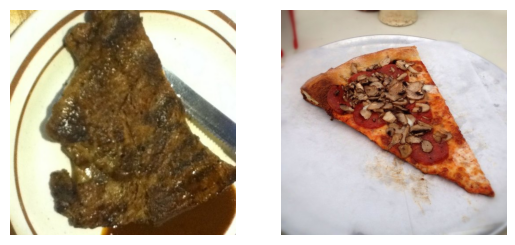

In [14]:
# visualize data
plt.figure()

plt.subplot(1, 2, 1)
steak_image = view_random_image("pizza_steak/train/", "steak"); # returns img array
plt.imshow(steak_image); plt.axis("off")

plt.subplot(1, 2, 2)
pizza_image = view_random_image("pizza_steak/train/", "pizza");
plt.imshow(pizza_image); plt.axis("off")

Turn the data into batches

In [15]:
# check out which gpu we're on
!nvidia-smi

Fri Jun 12 05:55:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             29W /   70W |    1147MiB /  15360MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
# create train and test data generators and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1/255.)

# This code initializes the "conveyor belt" system for your image data.

In [17]:
# load in our image data from directories and turn them into batches

train_data = train_datagen.flow_from_directory(directory = train_dir,
                                               target_size = (224, 224),
                                               class_mode = "binary",
                                               batch_size = 32)

test_data = train_datagen.flow_from_directory(directory = test_dir,
                                               target_size = (224, 224),
                                               class_mode = "binary",
                                               batch_size = 32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [18]:
# get a sample of a train data batch
images, labels = next(train_data)
len(images), len(labels) # its 32 due to our batch_size

(32, 32)

In [19]:
# how many batches are there?
len(train_data) # ~1500/32

47

In [20]:
# get the first 2 images and their shape
# images[:2], images[0].shape

# this is to ensure the array is normalized

In [21]:
# view the first batch of labels
labels # give, pizza or steak (training labels)

array([0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
       1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.],
      dtype=float32)

### Create a CNN model (start with a baseline)



In [22]:
# make creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [23]:
# create our baseline model

model_2 = Sequential([
    Conv2D(filters =10,
           kernel_size = 3,
           strides = 1,
           activation = "relu",
           input_shape = (224, 224, 3)), # imput_shape is needed only in the 1st layer
    Conv2D(10, 3, activation = "relu"), # the other hyperparameters is given via a handshake from the 1st layer
    Conv2D(10,3, activation = "relu"),
    Flatten(),
    Dense(1, activation = "sigmoid") # output layer => 1 neuron
])

In [24]:
# compile model_2
model_2.compile(loss = "binary_crossentropy",
                optimizer = Adam(),
                metrics = ["accuracy"])

In [25]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# check lengths of training and test data generators
len(train_data), len(test_data)

# fit model_2
history_2 = model_2.fit(train_data,
                        epochs = 5,
                        steps_per_epoch = len(train_data),
                        validation_data = test_data,
                        validation_steps = len(test_data))

'''
Because you are now using ImageDataGenerator (specifically flow_from_directory),
the labels are already "baked into" the train_data object itself. So  dont need
to pass train_labels seperately while fitting model_2
''';

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.6227 - loss: 0.9731 - val_accuracy: 0.8300 - val_loss: 0.4427
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.7960 - loss: 0.4523 - val_accuracy: 0.8520 - val_loss: 0.3751
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.8587 - loss: 0.3491 - val_accuracy: 0.8400 - val_loss: 0.3595
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.9367 - loss: 0.2006 - val_accuracy: 0.8240 - val_loss: 0.3576
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.9873 - loss: 0.0648 - val_accuracy: 0.8160 - val_loss: 0.4241


In [27]:
# evaluate model_2
model_2.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8160 - loss: 0.4241


[0.42407533526420593, 0.8159999847412109]

Evaluate the baseline model

<Axes: >

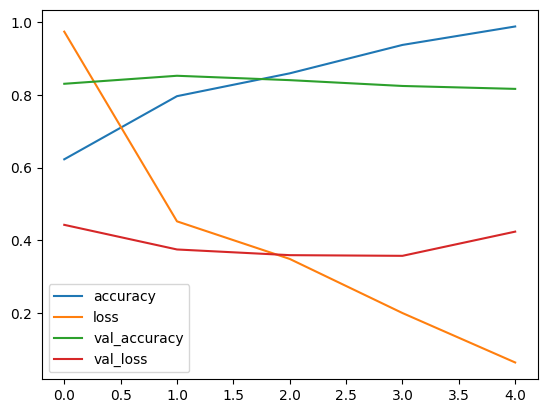

In [28]:
# plot the training curves
import pandas as pd
pd.DataFrame(history_2.history).plot()

In [29]:
# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();


  '''
  Ideally training and validation curves are supposed to be similar.
  If training loss is dec but validation moss is inc => overfitting
  '''

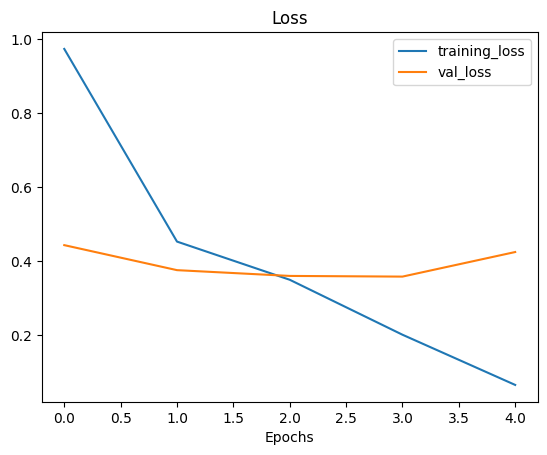

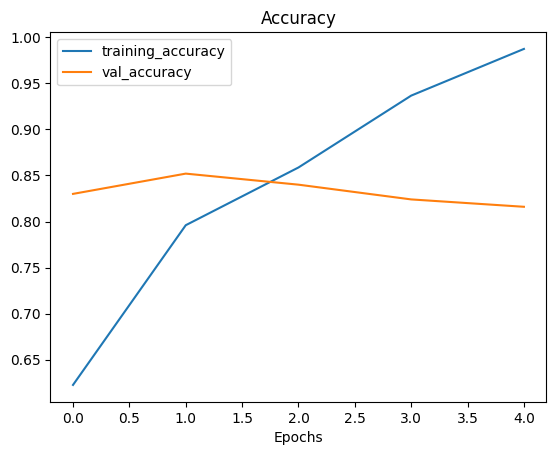

In [30]:
plot_loss_curves(history_2)

In [31]:
# Create the model (this can be our baseline, a 3 layer Convolutional Neural Network)

model_3 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# copile the model
model_3.compile(loss="BinaryCrossentropy",
                optimizer = Adam(),
                metrics = ["accuracy"])

In [33]:
# fit the model
history_3 = model_3.fit(train_data,
                        epochs = 5,
                        steps_per_epoch = len(train_data),
                        validation_data = test_data,
                        validation_steps = len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.6907 - loss: 0.6015 - val_accuracy: 0.8060 - val_loss: 0.4400
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.7880 - loss: 0.4580 - val_accuracy: 0.7240 - val_loss: 0.5120
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.8140 - loss: 0.4283 - val_accuracy: 0.8540 - val_loss: 0.3561
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.8307 - loss: 0.3915 - val_accuracy: 0.8680 - val_loss: 0.3348
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.8353 - loss: 0.3862 - val_accuracy: 0.8660 - val_loss: 0.3205


In [34]:
model_3.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.8660 - loss: 0.3205


[0.3204890191555023, 0.8659999966621399]

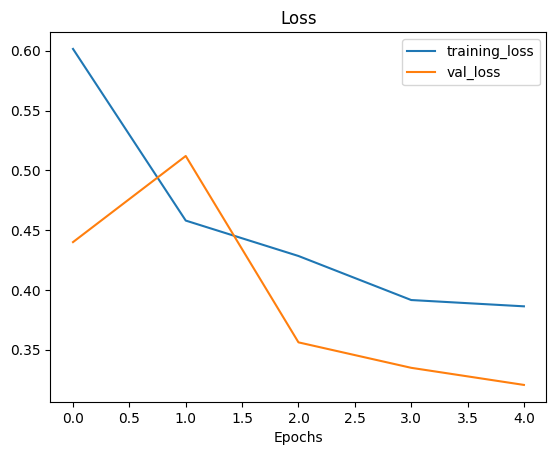

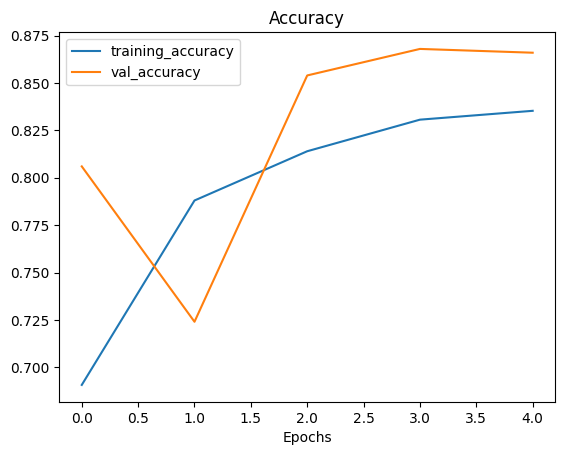

In [35]:
plot_loss_curves(history_3)

In [36]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

Reduce overfitting with augmentation

In [37]:

# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2, # how much do you want to rotate an image?
                                             shear_range=0.2, # how much do you want to shear an image?
                                             zoom_range=0.2, # zoom in randomly on an image
                                             width_shift_range=0.2, # move your iamge around on the x-axis
                                             height_shift_range=0.2, # move your image around on the y-axis
                                             horizontal_flip=True) # do you want to flip and image?

# Create ImageDataGenerator without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator without data augmentation for the test dataset
test_datagen = ImageDataGenerator(rescale=1/255.)

In [38]:
# Import data and augment it from training directory
print("Augmented training data:")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode="binary",
                                                                   shuffle=False) # for demonstration purposes only

# Create non-augmented train data batches
print("Non-augmented training data:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="binary",
                                               shuffle=False)

IMG_SIZE = (224, 224)
# Create non-augmented test data batches
print("Non-augmented test data:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMG_SIZE,
                                             batch_size=32,
                                             class_mode="binary")

Augmented training data:
Found 1500 images belonging to 2 classes.
Non-augmented training data:
Found 1500 images belonging to 2 classes.
Non-augmented test data:
Found 500 images belonging to 2 classes.


In [39]:
# Get sample data batches
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented) # note: labels aren't augmented... only data (images)

showing image number: 23


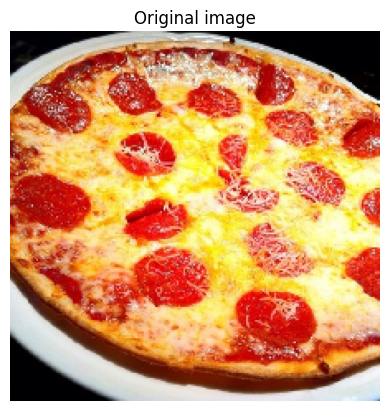

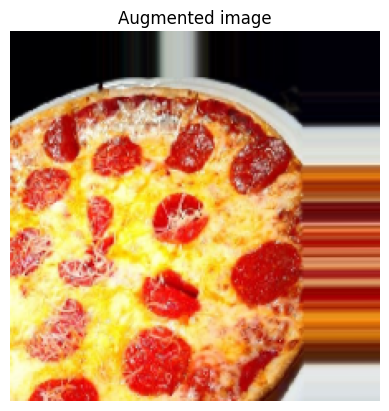

In [40]:
# Show original image and augmented image
import random
random_number = random.randint(0, 32) # our batch sizes are 32...
print(f"showing image number: {random_number}")
plt.imshow(images[random_number])
plt.title(f"Original image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image")
plt.axis(False);

In [41]:
model_4 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2),
  Conv2D(10, 3, activation="relu"),
  MaxPool2D(),
  Conv2D(10, 3, activation="relu"),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation="sigmoid")
])


In [42]:
model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [43]:
# Fit the model
history_4 = model_4.fit(train_data_augmented, # fitting model_4 on augmented training data
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - accuracy: 0.5293 - loss: 0.7475 - val_accuracy: 0.5780 - val_loss: 0.6831
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.5567 - loss: 0.7008 - val_accuracy: 0.7400 - val_loss: 0.6632
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 436ms/step - accuracy: 0.5280 - loss: 0.6953 - val_accuracy: 0.7300 - val_loss: 0.6623
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 456ms/step - accuracy: 0.6667 - loss: 0.6701 - val_accuracy: 0.6600 - val_loss: 0.6048
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 459ms/step - accuracy: 0.6760 - loss: 0.6205 - val_accuracy: 0.6620 - val_loss: 0.5700


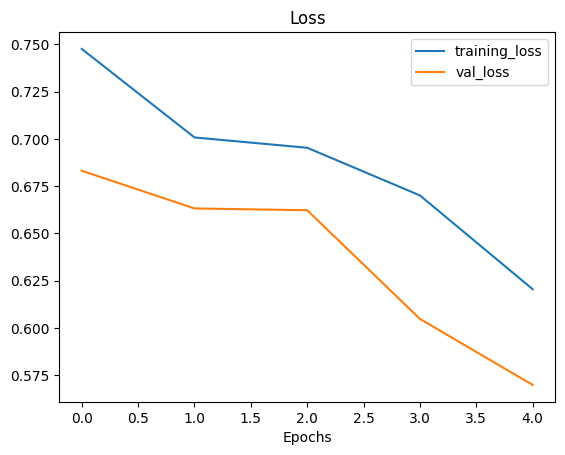

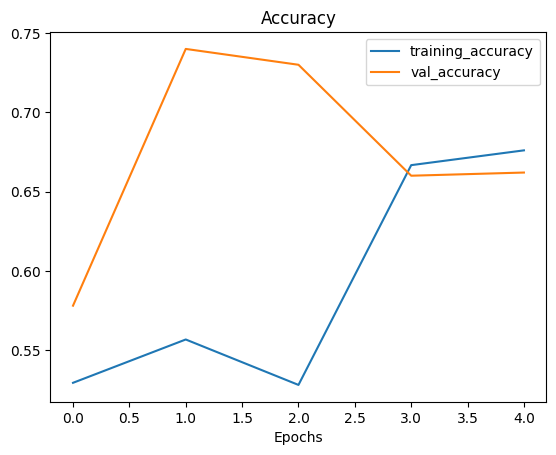

In [44]:
plot_loss_curves(history_4)

In [45]:
# Import data and augment it and shuffle from training directory
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size=(224, 224),
                                                                            class_mode="binary",
                                                                            batch_size=32,
                                                                            shuffle=True) # shuffle data this time


Found 1500 images belonging to 2 classes.


In [46]:
# Create the model (same as model_5 and model_6)
model_5 = Sequential([
  Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
  MaxPool2D(),
  Conv2D(10, 3, activation="relu"),
  MaxPool2D(),
  Conv2D(10, 3, activation="relu"),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation="sigmoid")
])

# Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit the model
history_5 = model_5.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 458ms/step - accuracy: 0.5947 - loss: 0.6680 - val_accuracy: 0.7720 - val_loss: 0.5487
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 433ms/step - accuracy: 0.7227 - loss: 0.5738 - val_accuracy: 0.8180 - val_loss: 0.4235
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 455ms/step - accuracy: 0.7347 - loss: 0.5338 - val_accuracy: 0.8060 - val_loss: 0.4360
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 463ms/step - accuracy: 0.7573 - loss: 0.5061 - val_accuracy: 0.7480 - val_loss: 0.4830
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 486ms/step - accuracy: 0.7540 - loss: 0.5036 - val_accuracy: 0.8020 - val_loss: 0.4374


In [47]:
model_5.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8020 - loss: 0.4374


[0.4373602271080017, 0.8019999861717224]

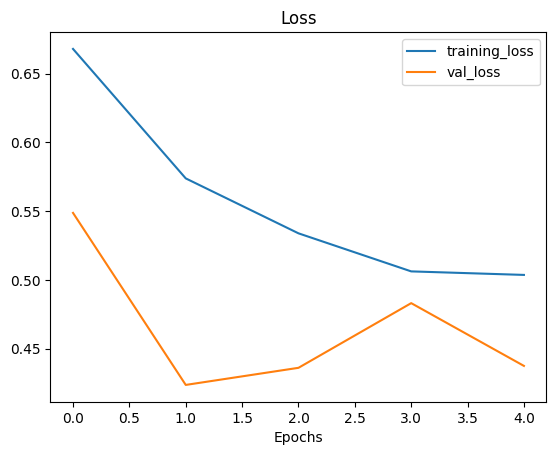

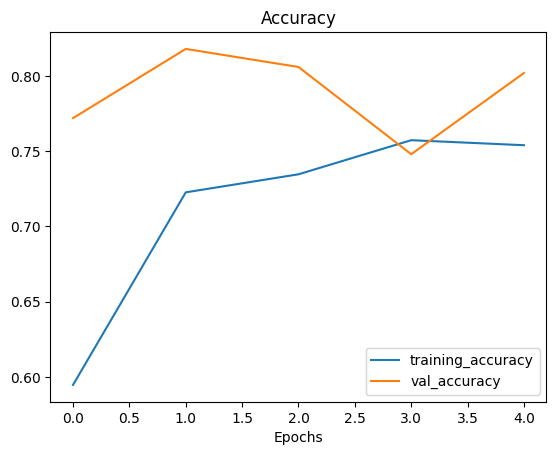

In [48]:
plot_loss_curves(history_5)

In [49]:
'''
Since we've already beaten our baseline, there are a few things we could try to contine to improve our model:

Increase the number of model layers (e.g. add more Conv2D/MaxPool2D layers)
Increase the number of filters in each convolutional layer (e.g. from 10 to 32 or even 64)
Train for longer (more epochs)
Find an ideal learning rate
Get more data (give the model more opportunities to learn)
Use transfer learning to leverage what another image model has learn and adjust it for our own use case
'''

"\nSince we've already beaten our baseline, there are a few things we could try to contine to improve our model:\n\nIncrease the number of model layers (e.g. add more Conv2D/MaxPool2D layers)\nIncrease the number of filters in each convolutional layer (e.g. from 10 to 32 or even 64)\nTrain for longer (more epochs)\nFind an ideal learning rate\nGet more data (give the model more opportunities to learn)\nUse transfer learning to leverage what another image model has learn and adjust it for our own use case\n"

### Making a prediction with our trained model on our custom data

--2026-06-12 06:00:41--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg’

03-steak.jpeg       100%[===================>]   1.89M  --.-KB/s    in 0.03s   

2026-06-12 06:00:41 (55.0 MB/s) - ‘03-steak.jpeg’ saved [1978213/1978213]



(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

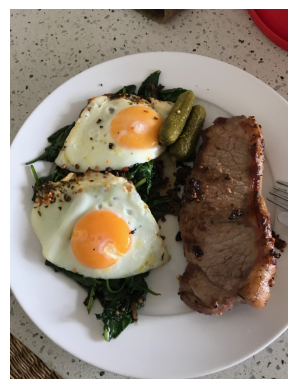

In [50]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Download the raw image file from GitHub
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg -O 03-steak.jpeg

# View our example image
steak = mpimg.imread("03-steak.jpeg")
plt.imshow(steak)
plt.axis(False)

In [51]:
# check shape
steak.shape

(4032, 3024, 3)

In [52]:
def preprocess_image(image_path, target_size=(224, 224)):
  # Load image
  img = mpimg.imread(image_path)
  # Resize image
  img = tf.image.resize(img, target_size)
  # Rescale pixel values to 0-1 (as done during training)
  img = img / 255.0
  # Add a batch dimension (model expects input in batches)
  img = tf.expand_dims(img, axis=0)
  return img

# Preprocess the custom steak image
preprocessed_steak = preprocess_image("03-steak.jpeg")

# Make a prediction with model_5
prediction_prob = model_5.predict(preprocessed_steak)
prediction_prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


array([[0.84388214]], dtype=float32)

In [53]:
prediction_class = class_names[round(prediction_prob[0][0].item())]
print(f"The predicted output is: {prediction_class}")
print(f"Confidence of {prediction_prob[0][0].item()*100}%")

The predicted output is: steak
Confidence of 84.3882143497467%


### Save and load our model

In [54]:
# Save model_5
model_5.save("Model_5_trained_pizza_steak_binary.keras")

In [55]:
# load in a trained model
loaded_model_5 = tf.keras.models.load_model("Model_5_trained_pizza_steak_binary.keras")
loaded_model_5.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8020 - loss: 0.4374


[0.4373601973056793, 0.8019999861717224]

In [56]:
# eval should be same as original since a random seed is set in the starting cells
model_5.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8020 - loss: 0.4374


[0.43736016750335693, 0.8019999861717224]